In [1]:
import StimCircuits.stimcircuits.surface_code as sc
import simulation as sim
import stim
import numpy as np

In [2]:
code = sim.SurfaceCodeBuilder().build_code(rounds=3, noise=0.1, code_task="surface_code:rotated_memory_z")

circuit = code.circuit

coordinates = sim.get_circuit_coordinates(circuit)

# for qubit in coordinates["qubits"]:
#     print(qubit)

# for detector in coordinates["detectors"]:
#     print(detector)

sample = sim.sample_logical_errors(circuit, num_shots=1)
print(sample.detection_events)

syndromes = sim.get_syndromes_from_detection_events(code, sample.detection_events)
print("Syndromes:")
print(syndromes)

[[ True False False False False  True False  True False False False False
   True  True False False  True  True  True  True False False False False]]
Syndromes:
[[[0 0 1 0 0 0 0 0]
  [1 1 1 0 0 0 0 0]
  [0 1 0 1 1 0 1 1]]]


In [3]:
print(circuit.flattened())

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19
X_ERROR(0.1) 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
X_ERROR(0.1) 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.1) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
DEPOLARIZE1(0.1) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.1) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.1) 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
DEPOLARIZE2(0.1) 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
DEPOLARIZE2(0.1) 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
DEPOLARIZE1(0.1) 2 11 16 25
TICK
X_ERROR(0.1) 2 9 11

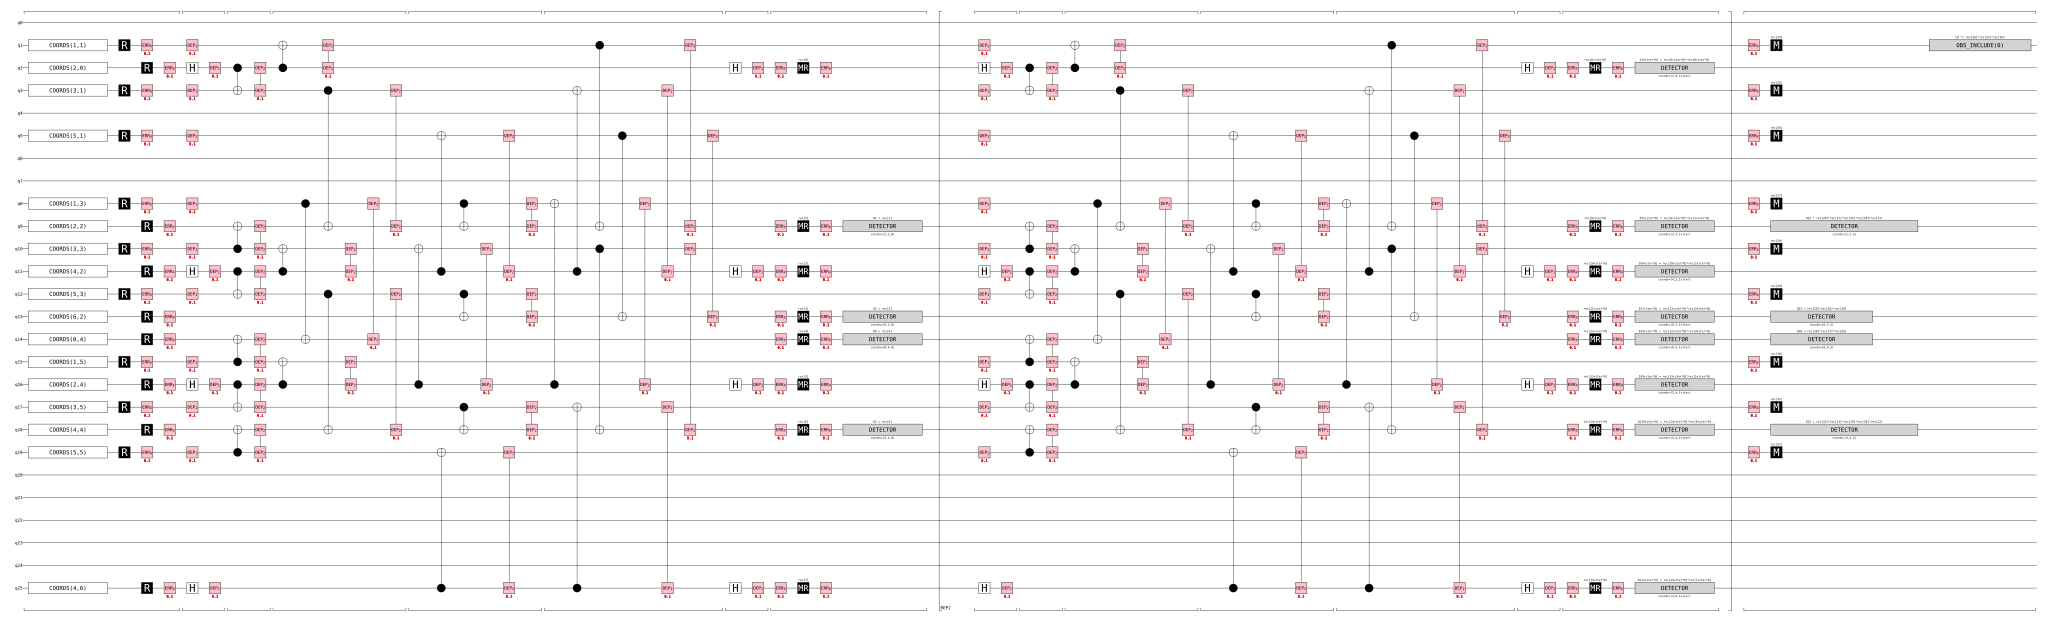

In [4]:
circuit.diagram("timeline-svg")

In [5]:
syndromes = np.array([[[0, 1, 1],
                        [1, 0, 1],
                        [1, 0, 1]],
                       [[1, 0, 1],
                        [1, 0, 1],
                        [1, 0, 1]]])

counts = sim.count_syndromes_per_shot(syndromes)
print(counts)

print(sim.get_syndrome_probabilities(syndromes, alpha=2))

[{'011': 1, '101': 2}, {'101': 3}]
[0.         0.         0.         0.         0.         0.66666667
 0.         0.        ]


Syndromes:
[[[0 1 1 ... 0 0 0]
  [0 0 1 ... 1 1 0]
  [1 1 1 ... 1 1 1]]

 [[0 1 1 ... 0 0 0]
  [1 1 1 ... 1 0 0]
  [0 1 1 ... 1 0 0]]

 [[0 1 0 ... 0 0 0]
  [0 1 1 ... 1 0 0]
  [1 0 0 ... 0 1 0]]

 ...

 [[0 0 1 ... 0 0 0]
  [0 0 1 ... 1 1 0]
  [1 0 0 ... 0 1 1]]

 [[0 0 1 ... 0 0 0]
  [0 1 1 ... 0 0 1]
  [1 0 1 ... 0 1 1]]

 [[0 0 1 ... 0 0 0]
  [0 1 0 ... 0 1 0]
  [0 1 0 ... 1 0 0]]]


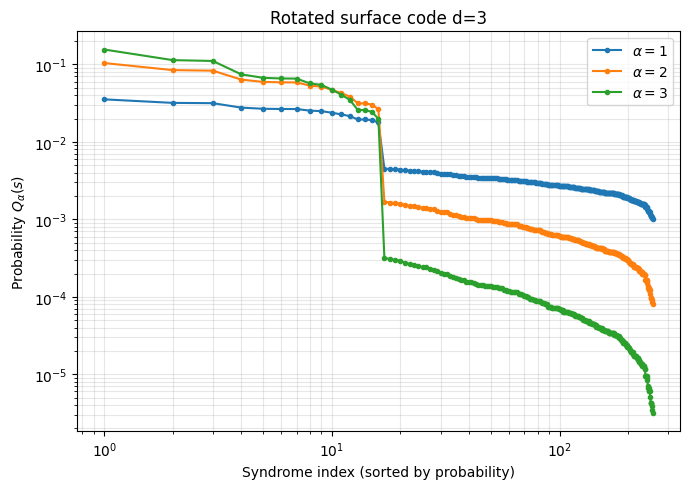

In [ ]:
code = sim.SurfaceCodeBuilder().build_code(
    distance=3,
    rounds=3,
    noise=0.2,
    code_task="surface_code:rotated_memory_z",
    noise_model="bit_flip",
)

sample = sim.sample_logical_errors(
    code.circuit,
    num_shots=100000,
)

syndromes = sim.get_syndromes_from_detection_events(
    code,
    sample.detection_events,
)

print("Syndromes:")
print(syndromes)

sim.plot_q_alpha_distribution(
    syndromes,
    alphas=(1, 2, 3),
    title="Rotated surface code d=3",
)

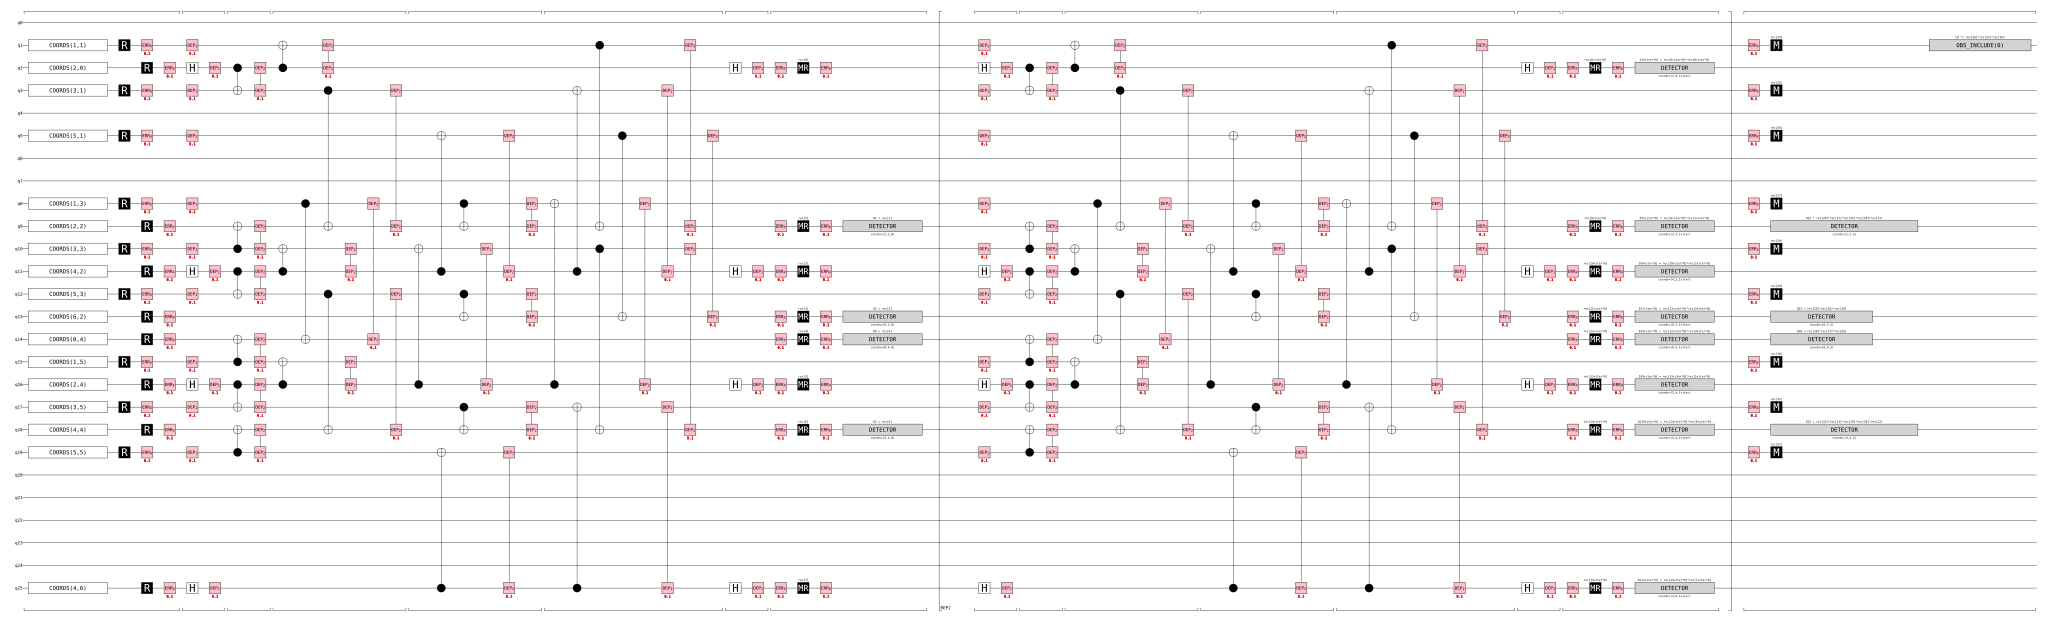

In [7]:
circuit.diagram('timeline-svg')

In [8]:
params = {
    "code_task": "surface_code:unrotated_memory_z",
    "rounds": 2,
    "distance": 3,
    "after_clifford_depolarization": 0.001,
    "before_round_data_depolarization": 0.002,
    "before_measure_flip_probability": 0.003,
    "after_reset_flip_probability": 0.004,
}

In [9]:
circuit = sc.generate_circuit(**params)

In [10]:
print(circuit.num_detectors)

24


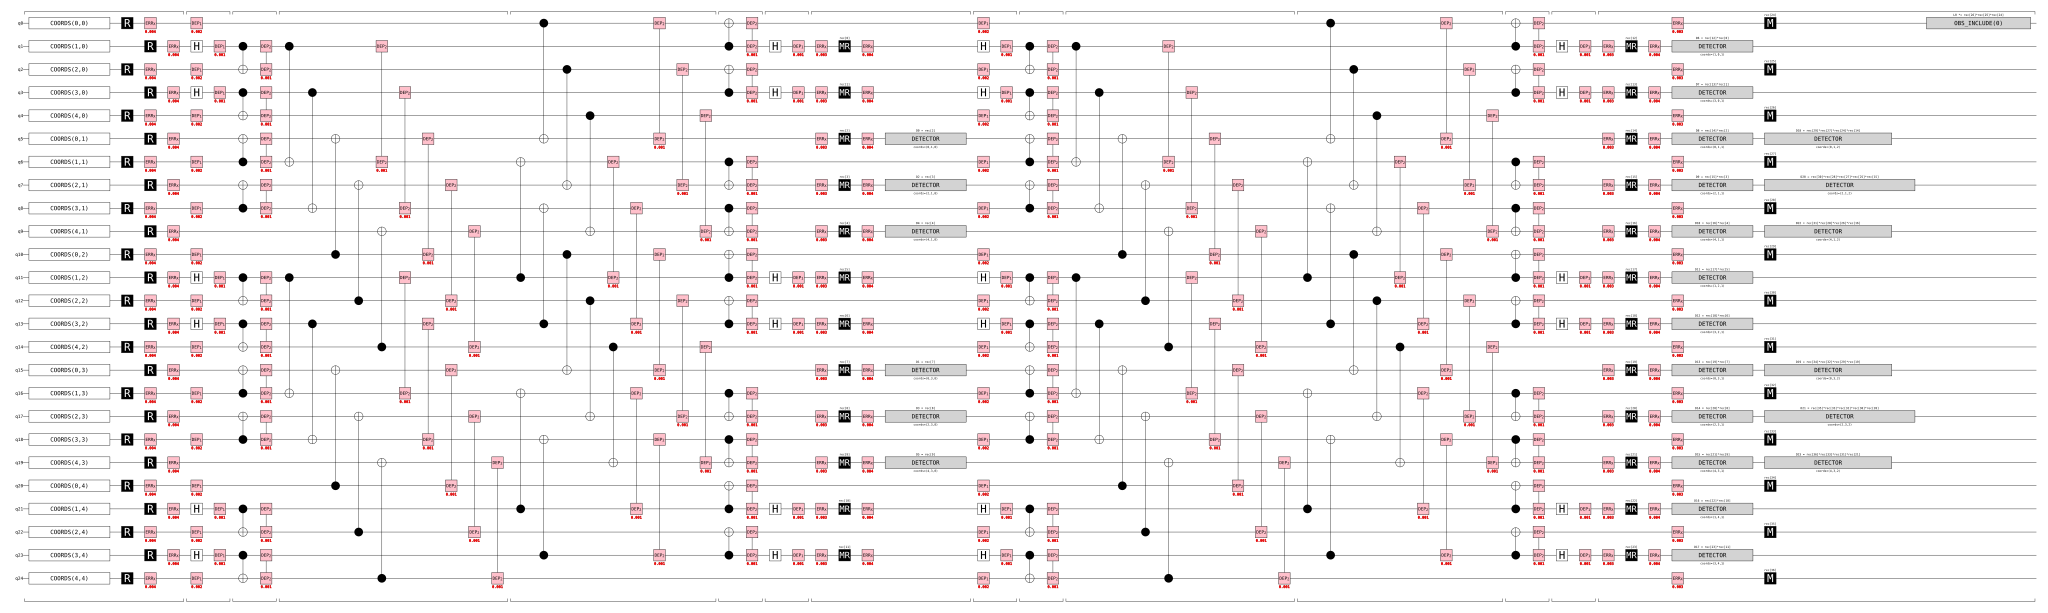

In [11]:
circuit.diagram('timeline-svg')

In [12]:
code_builder = sim.SurfaceCodeBuilder()

In [13]:
noise_params = {
    "after_clifford_depolarization": 0.001,
    "before_round_data_depolarization": 0.002,
    "before_measure_flip_probability": 0.003,
    "after_reset_flip_probability": 0.004,
}

there were 226 wrong predictions (logical errors) out of 100000 shots


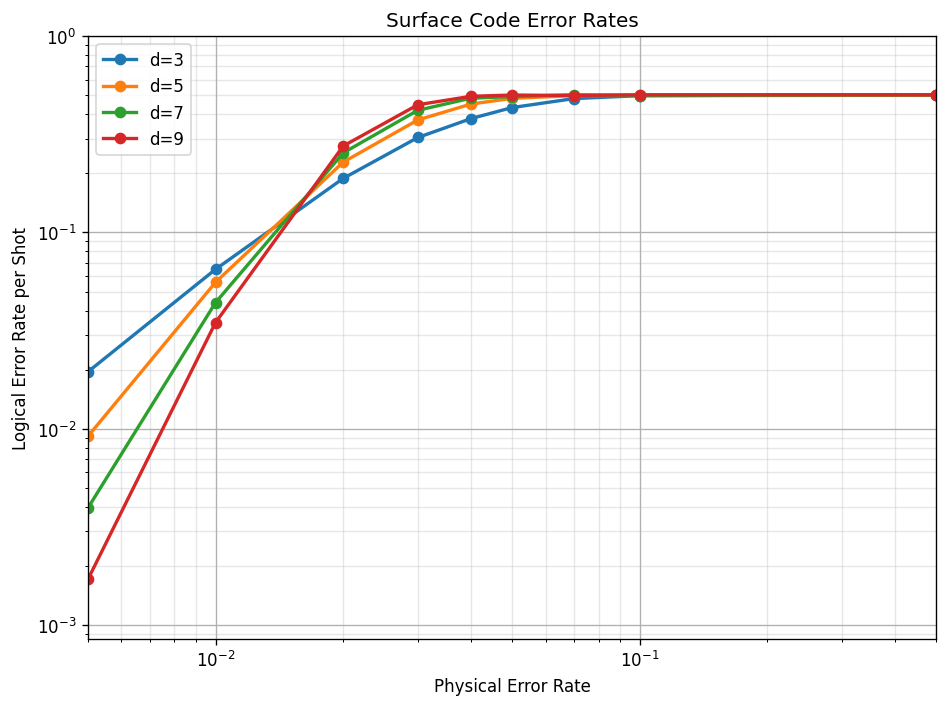

In [14]:
num_shots = 100_000
num_logical_errors = sim.count_logical_errors(circuit, num_shots)
print("there were", num_logical_errors, "wrong predictions (logical errors) out of", num_shots, "shots")
simulator = sim.SinisterSimulation(code_builder, max_shots=num_shots, noise_values=(0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.5), distances=(3, 5, 7, 9))
stats = simulator.run()


simulator.plot(stats, title="Surface Code")

In [15]:
import importlib
import simulation

importlib.reload(simulation)

one_experiment = simulation.sample_logical_errors(circuit, num_shots=1)
print('logical errors:', one_experiment.num_errors)
print('detection events:', one_experiment.detection_events)
print('observable flips:', one_experiment.observable_flips)
print('number of detectors:', circuit.num_detectors)


logical errors: 0
detection events: [[False False False False  True  True False False False False False False
  False False False False False False False False False False False False]]
observable flips: [[False]]
number of detectors: 24


In [16]:
simulator = sim.SinisterSimulation(

    sim.SurfaceCodeBuilder(),

    rounds=300,

    code_task="surface_code:rotated_memory_z",

    max_shots=2,

    noise_values=(0.7,),

    noise_model="bit_flip",

    distances=(3,),

)



rates = simulator.run_alpha_sweep(

    alphas=(1.0,),

)



# simulator.plot_alpha_sweep(

#     rates,

#     alphas=(1.0,),

#     title="Surface Code alpha sweep",

# )

ValueError: operands could not be broadcast together with shapes (256,) (2,) 